In [3]:
with open("../data/PSCompPars.csv", "r") as f:
    for i, line in enumerate(f):
        if not line.startswith("#"):
            print("First data line:", i)
            print(line[:500])
            break

First data line: 323
rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,sy_pnum,sy_mnum,cb_flag,discoverymethod,disc_year,disc_refname,disc_pubdate,disc_locale,disc_facility,disc_telescope,disc_instrument,rv_flag,pul_flag,ptv_flag,tran_flag,ast_flag,obm_flag,micro_flag,etv_flag,ima_flag,dkin_flag,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbper_reflink,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_orbsmax_reflink,pl_angsep,pl_angseperr1,pl


In [4]:
import pandas as pd

df = pd.read_csv(
    "../data/PSCompPars.csv",
    comment="#"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.shape

(6298, 320)

In [6]:
df.columns.tolist()

['rowid',
 'pl_name',
 'hostname',
 'pl_letter',
 'hd_name',
 'hip_name',
 'tic_id',
 'gaia_dr2_id',
 'gaia_dr3_id',
 'sy_snum',
 'sy_pnum',
 'sy_mnum',
 'cb_flag',
 'discoverymethod',
 'disc_year',
 'disc_refname',
 'disc_pubdate',
 'disc_locale',
 'disc_facility',
 'disc_telescope',
 'disc_instrument',
 'rv_flag',
 'pul_flag',
 'ptv_flag',
 'tran_flag',
 'ast_flag',
 'obm_flag',
 'micro_flag',
 'etv_flag',
 'ima_flag',
 'dkin_flag',
 'pl_controv_flag',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbper_reflink',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_orbsmax_reflink',
 'pl_angsep',
 'pl_angseperr1',
 'pl_angseperr2',
 'pl_angseplim',
 'pl_angsep_reflink',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_rade_reflink',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_radj_reflink',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmasse_reflink',
 'pl_bmassj',
 'pl_bma

In [7]:
[col for col in df.columns if "type" in col.lower()]

['st_spectype', 'st_spectype_reflink']

NASA does not provide planet category only Star Spectral Type (G2V, K-type, M-type stars, etc.) so we create planet caegory

In [8]:
df.head()

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,...,sy_kepmagerr1,sy_kepmagerr2,sy_kepmag_reflink,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,2,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,2.0,1.0,2.0,0.0,0.0,0.0,0.0
1,2,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,3,14 And b,14 And,b,HD 221345,HIP 116076,TIC 333225860,Gaia DR2 1920113512486282240,Gaia DR3 1920113512486282240,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,4,14 Her b,14 Her,b,HD 145675,HIP 79248,TIC 219483057,Gaia DR2 1385293808145621504,Gaia DR3 1385293808145621504,1,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,1.0,1.0,4.0,1.0,0.0,0.0,0.0
4,5,16 Cyg B b,16 Cyg B,b,HD 186427,HIP 96901,TIC 27533327,Gaia DR2 2135550755683407232,Gaia DR3 2135550755683407232,3,...,NaN,NaN,<a refstr=STASSUN_ET_AL__2019 href=https://ui....,5.0,1.0,4.0,3.0,0.0,0.0,0.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Columns: 320 entries, rowid to pl_ndispec
dtypes: float64(235), int64(5), str(80)
memory usage: 15.4 MB


#### **Celestia - Phase 1 Data Understanding**
Dataset: NASA Exoplanet Archive (PSCompPars)
- 6,298 planets
- 320 columns
- 240 numerical columns
- 80 text columns
- Dataset loads successfully after ignoring metadata lines (#)

In [10]:
df.isnull().sum().sort_values(ascending=False).head(20)

pl_angseperr2           6298
sy_kepmagerr2           6298
pl_angseperr1           6298
sy_kepmagerr1           6298
sy_icmagerr2            6280
pl_occdeperr1           6266
pl_occdeperr2           6266
pl_occdep               6263
pl_occdeplim            6263
pl_occdep_reflink       6263
pl_trueobliqerr1        6237
pl_trueobliqerr2        6237
pl_trueobliq            6231
pl_trueobliqlim         6231
pl_trueobliq_reflink    6231
sy_icmagerr1            6082
pl_projobliqerr1        6075
pl_projobliqerr2        6075
pl_projobliq_reflink    6074
pl_projobliqlim         6074
dtype: int64

In [11]:
(df.isnull().sum() / len(df) * 100).sort_values().head(30)

rowid                0.000000
pl_name              0.000000
hostname             0.000000
pl_letter            0.000000
disc_refname         0.000000
discoverymethod      0.000000
cb_flag              0.000000
sy_mnum              0.000000
sy_pnum              0.000000
sy_snum              0.000000
disc_year            0.015878
dkin_flag            0.079390
obm_flag             0.079390
ast_flag             0.079390
tran_flag            0.079390
ptv_flag             0.079390
pul_flag             0.079390
rv_flag              0.079390
disc_instrument      0.079390
disc_telescope       0.079390
disc_facility        0.079390
disc_locale          0.079390
disc_pubdate         0.079390
micro_flag           0.079390
pl_controv_flag      0.079390
ima_flag             0.079390
etv_flag             0.079390
pl_bmasse_reflink    0.158781
pl_bmassprov         0.158781
pl_bmassj_reflink    0.158781
dtype: float64

In [12]:
core_features = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbper",
    "pl_orbsmax",
    "pl_eqt",
    "st_mass",
    "st_rad",
    "st_teff"
]

df[core_features].isnull().sum()

pl_rade         60
pl_bmasse       41
pl_dens        151
pl_orbper      345
pl_orbsmax     435
pl_eqt        1613
st_mass         32
st_rad         340
st_teff        314
dtype: int64

In [13]:
df["pl_name"].duplicated().sum()

np.int64(0)

In [14]:
core_features = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbper",
    "pl_orbsmax",
    "pl_eqt"
]

df[core_features].describe()

,pl_rade,pl_bmasse,pl_dens,pl_orbper,pl_orbsmax,pl_eqt
count,6238.000000,6257.000000,6147.000000,5.953000e+03,5863.000000,4685.000000
mean,5.805911,399.578297,4.841406,7.190573e+04,15.652660,913.692333
std,5.404937,1130.684394,34.166999,5.212683e+06,348.180059,462.539233
min,0.309800,0.020000,0.005100,9.070629e-02,0.004400,34.000000
25%,1.840000,4.270000,1.300000,4.307440e+00,0.052395,568.100000
50%,2.840000,9.200000,2.530000,1.069526e+01,0.102330,822.000000
75%,11.898182,184.022648,4.540000,3.809722e+01,0.305450,1162.000000
max,87.205870,9534.852210,2000.000000,4.020000e+08,19000.000000,4050.000000


<Axes: >

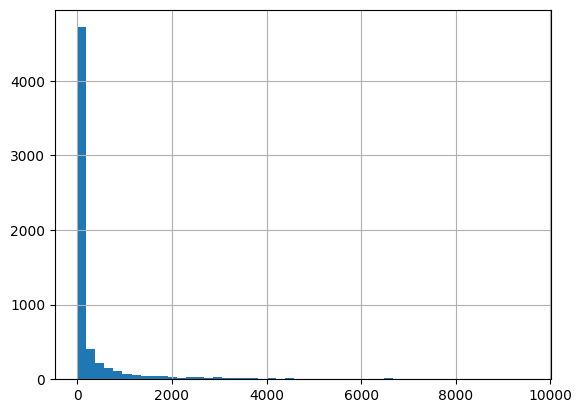

In [15]:
df["pl_bmasse"].hist(bins=50)

Planet mass is highly right-skewed.

Median mass = 9.2 Earth masses |    Mean mass = 399.6 Earth masses

The distribution contains extreme outliers,
suggesting future transformations may be required
before clustering.

<Axes: >

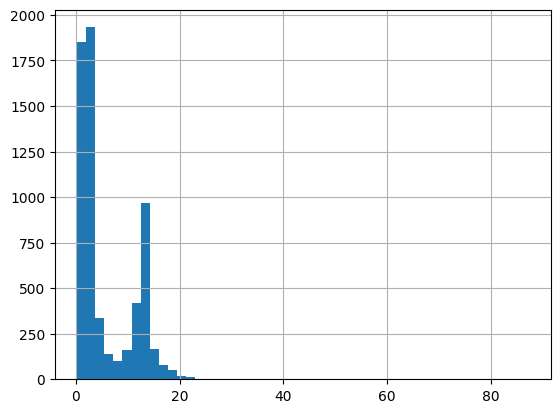

In [16]:
df["pl_rade"].hist(bins=50)

Multiple Populations- Different populations of planets may already exist in the data.

<Axes: xlabel='pl_rade', ylabel='pl_bmasse'>

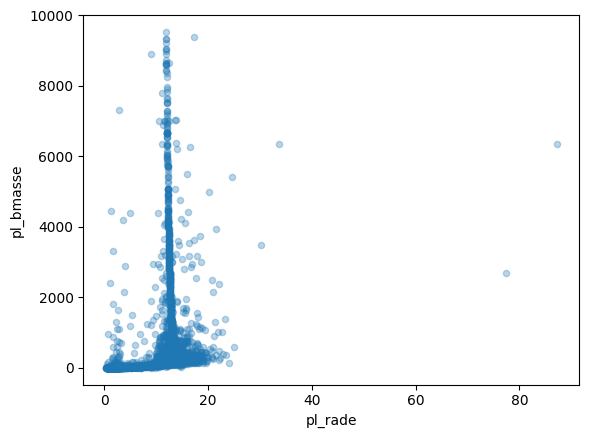

In [17]:
df.plot.scatter(
    x="pl_rade",
    y="pl_bmasse",
    alpha=0.3
)

extremly skewed data but forms size based groups, many outlines, def need log transformations and scaling

<Axes: >

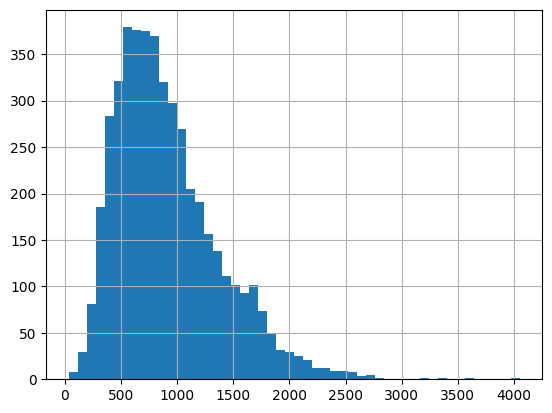

In [18]:
df["pl_eqt"].hist(bins=50)

Relatively Smooth

In [20]:
core_features = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbper",
    "pl_orbsmax",
    "pl_eqt"
]

df[core_features].corr()

,pl_rade,pl_bmasse,pl_dens,pl_orbper,pl_orbsmax,pl_eqt
pl_rade,1.000000,0.456949,-0.043439,0.019642,0.056258,0.426942
pl_bmasse,0.456949,1.000000,0.156286,0.029907,0.167108,0.252039
pl_dens,-0.043439,0.156286,1.000000,0.000729,0.010964,0.000460
pl_orbper,0.019642,0.029907,0.000729,1.000000,0.996708,-0.011932
pl_orbsmax,0.056258,0.167108,0.010964,0.996708,1.000000,0.070317
pl_eqt,0.426942,0.252039,0.000460,-0.011932,0.070317,1.000000


orbital period --> orbital distance

In [21]:
df[[
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_eqt",
    "st_mass",
    "st_rad",
    "st_teff"
]].describe()

,pl_rade,pl_bmasse,pl_dens,pl_eqt,st_mass,st_rad,st_teff
count,6238.000000,6257.000000,6147.000000,4685.000000,6266.000000,5958.000000,5984.000000
mean,5.805911,399.578297,4.841406,913.692333,0.933320,1.488505,5391.799651
std,5.404937,1130.684394,34.166999,462.539233,0.387419,3.881829,1733.867476
min,0.309800,0.020000,0.005100,34.000000,0.009400,0.011500,415.000000
25%,1.840000,4.270000,1.300000,568.100000,0.770000,0.770000,4897.000000
50%,2.840000,9.200000,2.530000,822.000000,0.940000,0.950000,5541.000000
75%,11.898182,184.022648,4.540000,1162.000000,1.082000,1.240000,5895.000000
max,87.205870,9534.852210,2000.000000,4050.000000,9.100000,88.475000,57000.000000


The dataset appears to contain:

Multiple planet populations
Strongly varying planetary sizes
Strongly varying masses
Rich stellar information 

This clustring is needed




## Phase 1 Findings
Dataset Quality
Metric	Result
Rows	6,298 planets
Columns	320
Duplicate planets	0
Core feature completeness	Excellent
Planet Features
Radius (pl_rade)
Median = 2.84 Earth radii

Observations:

Appears multimodal
Possible evidence of different planet populations
Mass (pl_bmasse)
Median = 9.2 Earth masses
Mean = 399.6 Earth masses

Observations:

Extremely right-skewed
Contains massive outliers
Density (pl_dens)
Median = 2.53

Observations:

Potentially unique information
Weak correlation with radius and mass
Temperature (pl_eqt)
Median = 822 K

Observations:

Fairly smooth distribution
Much better behaved than mass
Star Features
Star Mass (st_mass)
Median = 0.94 Solar masses

Interesting:

Most planets orbit stars similar to the Sun
Star Radius (st_rad)
Median = 0.95 Solar radii

Again:

Many host stars are Sun-like
Star Temperature (st_teff)
Median = 5541 K

The Sun is about:

5778 K

So a large portion of the sample consists of Sun-like stars.

Correlation Findings
Near-perfect correlation
pl_orbper ↔ pl_orbsmax = 0.997

These likely contain almost the same information.

Moderate correlation
pl_rade ↔ pl_bmasse = 0.457

Larger planets tend to be more massive, but not perfectly.

Good news for clustering.

<Axes: xlabel='pl_orbsmax', ylabel='pl_orbper'>

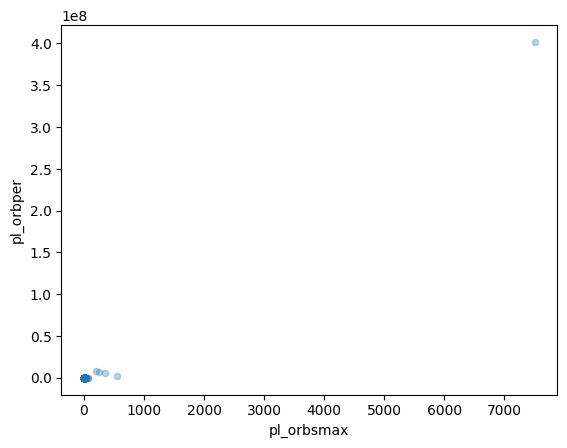

In [22]:
df.plot.scatter(
    x="pl_orbsmax",
    y="pl_orbper",
    alpha=0.3
)

In [23]:
df[["pl_orbper", "pl_orbsmax"]].isnull().sum()

pl_orbper     345
pl_orbsmax    435
dtype: int64

<Axes: xlabel='pl_orbsmax', ylabel='pl_eqt'>

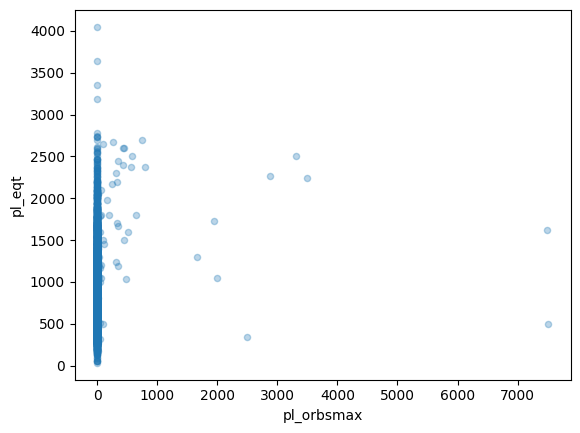

In [24]:
df.plot.scatter(
    x="pl_orbsmax",
    y="pl_eqt",
    alpha=0.3
)

gives us understanding that distance alone does not give us planet temperature